# Теперь займемся подготовкой спаршенного датасета
* Разберемся с пропусками
* Преобразуем имеющиеся признаки и выведем новые
* Сформируем финальное описание признаков датасета

In [1027]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
df_final = pd.read_csv("../../data/df_final.csv")

In [1028]:
df_final

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,type,first_release_date,genres,rating,rating_count,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch
0,1313940,My Holiday 2,This is the second part of the long holiday of...,259 руб.,1.00000,Очень положительные,106.00000,0.00000,NaN,NaN,...,Official Website,2020-10-05,Indie,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1902870,Vertical Kingdom,Возродите былое величие Империи в этой карточн...,710 руб.,1.00000,В основном положительные,111.00000,0.00000,NaN,NaN,...,"GOG, Nintendo",2024-04-15,"Puzzle, Strategy, Indie, Card & Board Game",NaN,NaN,NaN,NaN,0.00000,NaN,NaN
2,1071940,Streamer's Life,"Игра в жанре RPG-Simulation, в которой вам пре...",NaN,0.00000,В основном положительные,139.00000,0.00000,NaN,NaN,...,Steam,2019-07-31,"Role-playing (RPG), Simulator, Indie",NaN,NaN,NaN,NaN,NaN,NaN,0.00000
3,1706570,Chupacabras: Night Hunt,Hunt the chupacabras alone or with your friend...,99 руб.,1.00000,В основном положительные,124.00000,0.00000,NaN,NaN,...,NaN,2021-08-20,"Shooter, Indie",NaN,NaN,NaN,NaN,0.00000,NaN,NaN
4,1085150,Golf Defied,"Физика и механики нового поколения, мультиплее...",Бесплатные,1.00000,Смешанные,175.00000,0.00000,NaN,NaN,...,NaN,2019-03-11,"Simulator, Sport, Indie",NaN,NaN,NaN,NaN,0.00000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25696,1547900,Active Mummy,"Active Mummy — динамичный 2D-платформер, в кот...",210 руб.,1.00000,Положительные,20.00000,0.00000,NaN,NaN,...,Steam,2021-02-28,"Sport, Adventure, Indie",NaN,NaN,NaN,NaN,NaN,NaN,NaN
25697,2238360,You Have No Time,Rev up your inner speedster in this high-octan...,165 руб.,1.00000,Положительные,13.00000,0.00000,NaN,NaN,...,"Twitter, Discord, YouTube, Official Website",2023-11-09,"Puzzle, Indie",NaN,NaN,NaN,NaN,NaN,NaN,NaN
25698,1490030,Cyber Dodge,Cyber Dodge is a skill-based Runner and a Die ...,61 руб.,1.00000,Обзоров пользователей: 3,3.00000,0.00000,NaN,NaN,...,Steam,2021-02-14,Indie,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25699,1855190,Vektor Z,Vektor Z brings fast and furious retro space b...,280 руб.,1.00000,Обзоров пользователей: 2,2.00000,0.00000,NaN,NaN,...,"Discord, Official Website, Steam",2022-01-14,"Shooter, Indie, Arcade",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1029]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 25701 entries, 0 to 25700
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   steam_id                    25701 non-null  int64  
 1   game_name                   25701 non-null  str    
 2   game_description_snippet    25179 non-null  str    
 3   game_price                  19805 non-null  str    
 4   found_game_price            24747 non-null  float64
 5   all_language_reviews_type   24381 non-null  str    
 6   all_language_reviews_count  24381 non-null  float64
 7   has_russian_reviews         24747 non-null  float64
 8   all_russian_reviews_type    1534 non-null   str    
 9   all_russian_reviews_count   1534 non-null   float64
 10  steam_app_url               24747 non-null  str    
 11  support_ru_region           24747 non-null  float64
 12  igdb_id                     25701 non-null  int64  
 13  type                        12585 non-null

## Посмотрим на неудачно спаршенные игры

Посмотрев на вывод .info() по датасету можно заметить, что у нас есть ряд признаков, где у всех non-null значений по 24785. В частности, это бинарные T/F признаки found_game_price, has_russian_reviews, support_ru_region. То есть парсер не то что не смог найти значения или нет, он не смог определить/ответить есть они или нет.

In [1030]:
print(f'{df_final['found_game_price'].isna().sum() / df_final.shape[0] * 100}%')

3.7119178242091744%


И т.к. этих пропусков всего 3.7%, то можно их просто удалить

In [1031]:
df_final = df_final.dropna(subset=['found_game_price'])
df_final.info()

<class 'pandas.DataFrame'>
Index: 24747 entries, 0 to 25700
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   steam_id                    24747 non-null  int64  
 1   game_name                   24747 non-null  str    
 2   game_description_snippet    24726 non-null  str    
 3   game_price                  19805 non-null  str    
 4   found_game_price            24747 non-null  float64
 5   all_language_reviews_type   24381 non-null  str    
 6   all_language_reviews_count  24381 non-null  float64
 7   has_russian_reviews         24747 non-null  float64
 8   all_russian_reviews_type    1534 non-null   str    
 9   all_russian_reviews_count   1534 non-null   float64
 10  steam_app_url               24747 non-null  str    
 11  support_ru_region           24747 non-null  float64
 12  igdb_id                     24747 non-null  int64  
 13  type                        12108 non-null  str

Теперь у нас количество non-null значений в тех столбцах равно количеству строк в датасете

## Выборка наиболее репрезентативных строк

Т.к. в нашем датасете, что было еще визуально отмечено при сборе датасета, множество игр совсем непопулярных/неизвестных с очень ограниченной информацией, которая может является нашим таргетом - нам необходимо избавиться.

В нашем датасете есть 4 столбца, характеризующие рейтинг: 'rating', 'rating_count', 'total_rating', 'total_rating_count'.

Исходя из описания API: total_rating/total_rating_count это рейтинги п, есть случат, когда total столбцы такие же как просто rating - информация была только по одному основному, по всей видимости, IGDB рейтингу.

Можно посмотреть на распределение значений для обоих вариантов, взяв только те строки, где для всех 4 столбцов значения непустые (чтобы справедливо сравнить распределение)

In [1032]:
not_na_ratings = df_final[df_final[['rating', 'rating_count', 'total_rating', 'total_rating_count']].notna().all(axis=1)][['rating', 'rating_count', 'total_rating', 'total_rating_count']]

In [1033]:
pd.concat([not_na_ratings['rating'].describe(), not_na_ratings['total_rating'].describe()], axis=1)

,rating,total_rating
count,9936.00000,9936.00000
mean,64.75992,65.07484
std,12.50975,12.53944
min,10.79175,11.72456
25%,52.61456,56.03621
50%,70.00000,70.00000
75%,71.11955,73.33660
max,98.15237,98.09123


In [1034]:
print(f'Процент строк с равным значением для rating и total_rating {not_na_ratings[not_na_ratings['rating'] == not_na_ratings['total_rating']].shape[0] / not_na_ratings.shape[0] * 100}%')
print(f'Количество строк с непустыми значениями признака rating {df_final[df_final['rating'].notna()].shape[0]}')
print(f'Количество строк с непустыми значениями признака total_rating {df_final[df_final['total_rating'].notna()].shape[0]}')

Процент строк с равным значением для rating и total_rating 72.40338164251207%
Количество строк с непустыми значениями признака rating 9936
Количество строк с непустыми значениями признака total_rating 10349


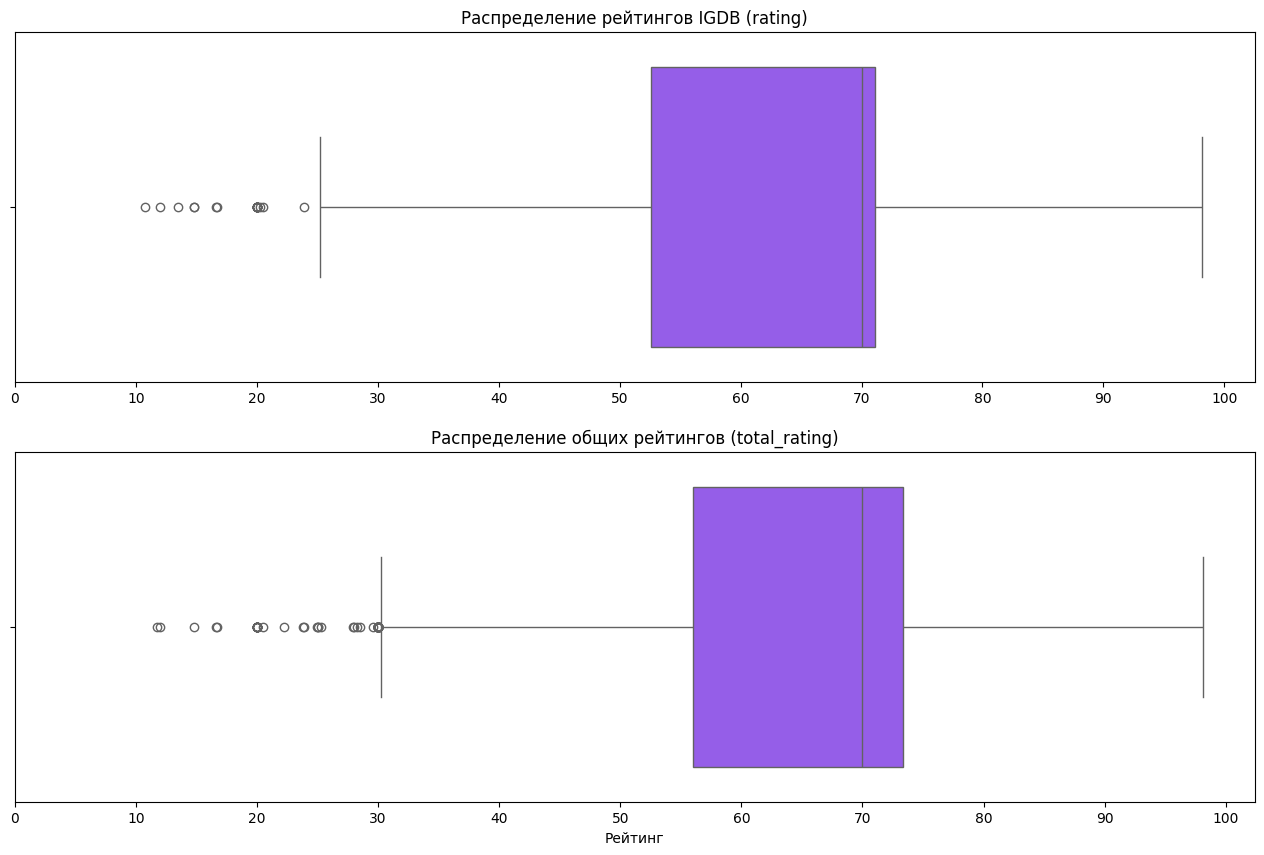

In [1035]:
plt.figure(figsize=(16, 10))

plt.subplot(2,1,1)
plt.title('Распределение рейтингов IGDB (rating)')
sns.boxplot(not_na_ratings, x='rating', color='#9147FF')
plt.xticks(range(0, 101, 10))
plt.xlabel('')

plt.subplot(2,1,2)
plt.title('Распределение общих рейтингов (total_rating)')
sns.boxplot(not_na_ratings, x='total_rating', color='#9147FF')
plt.xticks(range(0, 101, 10))
plt.xlabel('Рейтинг')

plt.show()

Можем заметить, что распределения несильно отличаются, медиана вовсе одинаковая, при этом строк с непустым значением в total_rating - больше. Так что оставим в датасете только total_rating и total_rating_count

In [1036]:
df_final = df_final.drop(columns=['rating', 'rating_count'])

Раннее мы заметили, что строк с непустым значением в total_rating у нас 10349. Но у нас есть еще признак total_rating_count, при этом - он может и каким-то образом быть равен 0:

In [1037]:
df_final[df_final['total_rating_count'] == 0]

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,support_ru_region,igdb_id,type,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch
13,741500,"John, The Zombie","Welcome to Johnwood, a weird and mysterious pl...",259 руб.,1.00000,Смешанные,179.00000,0.00000,NaN,NaN,...,1.00000,75333,"Nintendo, Official Website",2017-11-22,"Simulator, Indie",50.00000,0.00000,0.00000,NaN,NaN
20,463860,Shadows of Kurgansk,"Shadows of Kurgansk — игра, в которой вам пред...",200 руб.,1.00000,Смешанные,197.00000,0.00000,NaN,NaN,...,1.00000,26581,"Nintendo, Playstation",2016-12-15,"Role-playing (RPG), Simulator, Adventure, Indie",50.00000,0.00000,NaN,NaN,NaN
21,754540,Gauntlet of IRE,A 35 part obstacle course that is deceptively ...,Бесплатно,1.00000,В основном положительные,200.00000,0.00000,NaN,NaN,...,1.00000,76271,NaN,2017-12-15,Indie,70.00000,0.00000,NaN,NaN,NaN
25,454320,[the Sequence],[the Sequence] is a logic construction puzzler...,200 руб.,1.00000,Очень положительные,151.00000,0.00000,NaN,NaN,...,1.00000,33425,NaN,2016-03-30,Indie,80.00000,0.00000,0.00000,NaN,NaN
27,600630,Spaceship Looter,Spaceship Looter - игра жанра action roguelike...,Бесплатные,1.00000,В основном положительные,230.00000,0.00000,NaN,NaN,...,1.00000,29333,NaN,2017-05-17,"Role-playing (RPG), Adventure, Indie",50.00000,0.00000,0.00000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25643,415090,KByte,Kbyte is a platform/puzzle game made in variou...,82 руб.,1.00000,Положительные,27.00000,0.00000,NaN,NaN,...,1.00000,34109,"Twitch, Official Website, Steam",2017-02-24,Indie,70.00000,0.00000,NaN,NaN,NaN
25644,562800,HOUND,HOUND - не игра в привычном понимании - это эф...,NaN,0.00000,В основном отрицательные,63.00000,0.00000,NaN,NaN,...,1.00000,30316,Steam,2017-03-28,"Simulator, Indie",50.00000,0.00000,0.00000,NaN,NaN
25666,577470,Last Days Of Tascaria,Last Days Of Tascaria is a roguelite RPG where...,195 руб.,1.00000,В основном положительные,20.00000,0.00000,NaN,NaN,...,1.00000,99595,"Official Website, Steam",2019-10-04,"Role-playing (RPG), Strategy, Adventure, Indie",70.00000,0.00000,NaN,NaN,NaN
25669,845840,Laser Maze,Laser Maze is a puzzle game that takes place i...,133 руб.,1.00000,Положительные,17.00000,0.00000,NaN,NaN,...,1.00000,100243,Steam,2019-01-04,Indie,70.00000,0.00000,NaN,NaN,NaN


Таких строк 3248, но давайте посмотрим также на распределение признака all_language_reviews_count - количество обзоров в Steam. Посмотрим только на строки с наличием total_rating

In [1038]:
df_review_count_w_total_rating = df_final[(df_final['total_rating'].notna()) & (df_final['all_language_reviews_count'].notna())]['all_language_reviews_count']
# https://stackoverflow.com/questions/55394854/how-to-change-the-format-of-describe-output
pd.set_option('display.float_format', lambda x: '%.5f' % x)
df_review_count_w_total_rating.describe()

count     10347.00000
mean       4715.83879
std       42011.98263
min           1.00000
25%          87.50000
50%         277.00000
75%        1207.50000
max     2696908.00000
Name: all_language_reviews_count, dtype: float64

Уже здесь заметим, что у нас есть экстремально большие значения, но зато с минимумом 1, если не брать пропуски.

Но давайте примем за порог значения Q1 - 25%, где возьмем в финальный датасет те строки, в которых количество ревью больше, в данном случае, 87.5, даже если значение total_rating = 0.

In [1039]:
df_final_2 = df_final[((df_final['total_rating_count'] > 0) | (df_final['all_language_reviews_count'] >= 87.5)) & (df_final['total_rating'].notna())]
df_final_2

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,support_ru_region,igdb_id,type,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch
5,590970,Hollow,« Меня не интересовал этот корабль... комплекс...,419 руб.,1.00000,В основном отрицательные,231.00000,0.00000,NaN,NaN,...,1.00000,29525,"Nintendo, YouTube, Discord, Facebook, Twitter",2017-11-16,"Shooter, Puzzle, Adventure, Indie",50.00000,3.00000,0.00002,NaN,0.00000
9,709840,Bloody Glimpse,Bloody Glimpse will take you on a immersive jo...,42 руб.,1.00000,Смешанные,227.00000,0.00000,NaN,NaN,...,1.00000,59138,Twitch,2017-09-29,"Simulator, Indie",40.00000,1.00000,0.00000,NaN,NaN
13,741500,"John, The Zombie","Welcome to Johnwood, a weird and mysterious pl...",259 руб.,1.00000,Смешанные,179.00000,0.00000,NaN,NaN,...,1.00000,75333,"Nintendo, Official Website",2017-11-22,"Simulator, Indie",50.00000,0.00000,0.00000,NaN,NaN
15,713160,After Death,After Death is a platform / exploration game i...,299 руб.,1.00000,Очень положительные,146.00000,0.00000,NaN,NaN,...,1.00000,65786,NaN,2017-10-05,"Adventure, Indie",70.00000,3.00000,0.00001,NaN,NaN
20,463860,Shadows of Kurgansk,"Shadows of Kurgansk — игра, в которой вам пред...",200 руб.,1.00000,Смешанные,197.00000,0.00000,NaN,NaN,...,1.00000,26581,"Nintendo, Playstation",2016-12-15,"Role-playing (RPG), Simulator, Adventure, Indie",50.00000,0.00000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25607,318310,Choice of the Deathless,"Battle demons and undead attorneys, and win so...",200 руб.,1.00000,Очень положительные,307.00000,0.00000,NaN,NaN,...,1.00000,17744,"Steam, Official Website",2014-07-05,"Role-playing (RPG), Indie",77.50000,5.00000,0.00001,NaN,NaN
25624,818050,Wormster Dash,Prepare yourself for a one-of-its-kind platfor...,61 руб.,1.00000,Положительные,37.00000,0.00000,NaN,NaN,...,1.00000,89004,"Twitch, Official Website, Steam, Google Play",2018-03-29,"Adventure, Indie",44.68085,2.00000,0.00000,NaN,NaN
25639,709700,The Thing: Space X,At your disposal are a dozen of the best comba...,42 руб.,1.00000,Смешанные,52.00000,0.00000,NaN,NaN,...,1.00000,59143,Steam,2017-09-20,"Adventure, Indie",50.00000,1.00000,0.00000,NaN,NaN
25645,506150,Dragon Bros,Роботы заполонили собой все и уничтожают место...,199 руб.,1.00000,Положительные,20.00000,0.00000,NaN,NaN,...,1.00000,31970,"Steam, Official Website",2016-09-16,Indie,73.50000,1.00000,0.00000,NaN,NaN


Итого: осталось 8720 строк.

Огромная часть изначальной выборки, тем самым, мы выбросили, но в рамках нашей задачи - 8720 игр также довольно большое количество, с учетом того, что игр хоть и выходит много, но тех, которые достойны внимания - достаточно мало. Зато, наш анализ будет более репрезентативным и то большое число игр, фактически которые никакой полезной в себе информации об их успехе не несут - мы и не будем рассматривать.

In [1040]:
df_final_2.to_csv('../../data/df_final_2.csv', index=False)

## Займемся обработкой имеющихся столбцов
### Обработка колонки с ценой

Если у нас была найдена цена, то в рублях и тогда формат записи цены будет, к примеру: 165 руб.

Проверим, действительно ли везде рубли и можем ли мы тогда при наличии более 1 элемента после разделения по пробелу - удалить это обозначение валюты

In [1041]:
df_final_2['game_price'].str.split(' ').str[1].value_counts()

game_price
руб.           6360
to               29
To                1
WARMACHINE:       1
Name: count, dtype: int64

Посмотрим что за 31 строки с "to", "To" и "WARMACHINE"

In [1042]:
df_final_2[df_final_2['game_price'].str.contains('to')]

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,support_ru_region,igdb_id,type,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch
986,299420,CubeGun,A Sandbox Multiplayer Airship Shooting Game.De...,Free to Play,1.00000,Смешанные,321.00000,0.00000,NaN,NaN,...,1.00000,17372,NaN,2014-05-21,Indie,50.00000,0.00000,0.00000,NaN,NaN
8669,250420,8BitMMO,8BitMMO is a retro-style 2D massively multipla...,Free to Play,1.00000,Смешанные,4321.00000,1.00000,Смешанные,350.00000,...,1.00000,30232,NaN,2015-01-26,"Role-playing (RPG), Adventure, Indie",50.00000,2.00000,0.00001,NaN,NaN
12033,361630,404Sight,404Sight is a free game made in support of net...,Free to Play,1.00000,Очень положительные,1761.00000,0.00000,NaN,NaN,...,1.00000,19389,NaN,2015-04-16,"Platform, Indie",59.84732,6.00000,0.00001,NaN,NaN
15207,346250,The Old Tree,The Old Tree is a short free-to-play cinematic...,Free to Play,1.00000,Очень положительные,3312.00000,1.00000,Очень положительные,283.00000,...,1.00000,24610,Facebook,2012-02-24,"Point-and-click, Puzzle, Adventure, Indie",68.99882,8.00000,0.00001,NaN,NaN
17074,99900,Spiral Knights,Вступайте в ряды игроков Spiral Knights. Оказа...,Free to Play,1.00000,Очень положительные,23936.00000,1.00000,Очень положительные,1756.00000,...,1.00000,9265,"Facebook, YouTube",2011-04-04,"Role-playing (RPG), Adventure, Indie",56.33485,31.00000,NaN,NaN,NaN
17085,262410,World of Guns: Gun Disassembly,World of Guns: Guns Disassembly - настоящий ор...,Free to Play,1.00000,Очень положительные,19644.00000,1.00000,Очень положительные,3319.00000,...,1.00000,7555,"Twitch, Twitter, YouTube, Instagram, Community...",2014-05-21,"Shooter, Puzzle, Simulator, Indie",65.87225,14.00000,0.00003,0.00006,0.00000
17110,242720,GunZ 2: The Second Duel,GunZ 2: the Second Duel is a free-to-play 3D T...,Free to Play,1.00000,Смешанные,10632.00000,1.00000,В основном положительные,1116.00000,...,1.00000,16558,NaN,2014-04-04,"Shooter, Indie",40.50370,10.00000,NaN,NaN,NaN
17117,248570,Toribash,Toribash - это инновационный бесплатный пошаго...,Free to Play,1.00000,Очень положительные,16781.00000,1.00000,Очень положительные,1851.00000,...,1.00000,1875,NaN,2006-03-01,"Fighting, Simulator, Strategy, Indie",67.47328,26.00000,0.00007,NaN,0.00000
17137,212070,Star Conflict,Star Conflict — Это динамичный MMO экшн-симуля...,Free to Play,1.00000,В основном положительные,15094.00000,1.00000,В основном положительные,4428.00000,...,1.00000,3210,NaN,2012-07-24,"Shooter, Simulator",77.96430,9.00000,0.00008,0.00018,0.00000
17179,206500,AirMech,AirMech® Strike is a fast paced Action-RTS gam...,Free to Play,1.00000,Очень положительные,10818.00000,1.00000,Очень положительные,1438.00000,...,1.00000,1365,NaN,2018-03-30,"Real Time Strategy (RTS), Strategy, Tactical, ...",36.09393,13.00000,0.00008,NaN,NaN


In [1043]:
df_final_2[df_final_2['game_price'].str.contains('To')]

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,support_ru_region,igdb_id,type,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch
19448,298260,Only If,Only If is a surreal first person adventure-pu...,Free To Play,1.00000,Смешанные,5954.00000,1.00000,Смешанные,362.00000,...,1.00000,17354,NaN,2014-07-25,"Puzzle, Adventure, Indie",74.76254,19.00000,0.00004,NaN,NaN


In [1044]:
df_final_2[df_final_2['game_price'].str.contains('WARMACHINE:')]

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,support_ru_region,igdb_id,type,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch
24935,253510,WARMACHINE: Tactics,Turn-based tactical combat set in the award-wi...,Play WARMACHINE: Tactics Demo,1.00000,Смешанные,1160.00000,0.00000,NaN,NaN,...,1.00000,16695,NaN,2014-10-04,"Strategy, Indie",50.00000,1.00000,0.00002,NaN,0.00000


Вышло, что первые два случая это бесплатные игры, а у одной игры неверно нашлась цена, но видно что там есть демо версия, а значит платная версия.

Для этой одной игры можно было не полениться и посмотреть вручную цену - 419 руб. Заменим пока у нее цену, а также посмотрим как еще обозначаются бесплатные игры

In [1045]:
df_final_2.loc[df_final_2['steam_id'] == 253510, 'game_price'] = '419 руб.'
df_final_2[df_final_2['steam_id'] == 253510]

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,support_ru_region,igdb_id,type,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch
24935,253510,WARMACHINE: Tactics,Turn-based tactical combat set in the award-wi...,419 руб.,1.00000,Смешанные,1160.00000,0.00000,NaN,NaN,...,1.00000,16695,NaN,2014-10-04,"Strategy, Indie",50.00000,1.00000,0.00002,NaN,0.00000


In [1046]:
first_el_price = df_final_2['game_price'].str.split(' ').str[0].reset_index()
first_el_price['game_price'].value_counts()

game_price
385          389
550          327
200          320
42           302
Бесплатно    290
            ... 
208            1
346,85         1
100            1
2100           1
1349           1
Name: count, Length: 318, dtype: int64

Попробуем преобразовать все значения в числа, что не сможем - выведем

Также заметим, что нам здесь уже видно дробное число с зяпятой вместо точки для разделения целой и дробной частей. Заменим для начала запятые на точки. Сделаем это в исходном датасете

In [1047]:
df_final_2['game_price'] = df_final_2['game_price'].str.replace(',', '.')

In [1048]:
first_el_price = df_final_2['game_price'].str.split(' ').str[0].reset_index()
# https://stackoverflow.com/questions/73313363/how-to-deal-with-strings-on-a-numeric-column-in-pandas

first_el_price['game_price_nums'] = pd.to_numeric(first_el_price['game_price'], errors='coerce')

first_el_price.loc[first_el_price['game_price'].notna() & first_el_price['game_price_nums'].isna(), 'game_price'].value_counts()

game_price
Бесплатно     290
Бесплатные    238
Free           30
Name: count, dtype: int64

Мы нашли три варианта обозначения бесплатной игры, где "Free" как первый элемент это для строк, которые были найдены раньше, где значения "Free to Play" и "Free To Play"

Заменим их все на 0, а также уберем "руб."

In [1049]:
df_final_2['game_price'] = df_final_2['game_price'].str.replace('Бесплатно', '0')
df_final_2['game_price'] = df_final_2['game_price'].str.replace('Бесплатные', '0')
df_final_2['game_price'] = df_final_2['game_price'].str.replace('Free to Play', '0')
df_final_2['game_price'] = df_final_2['game_price'].str.replace('Free To Play', '0')
df_final_2['game_price'] = df_final_2['game_price'].str.replace('руб.', '')

Попробуем теперь применить pd.to_numeric уже в исходном df и без указания errors='coerce'. Если все пройдет без ошибок, знвчит все значения числовые, если будет ошибка то продолжим разбираться

In [1050]:
df_final_2['game_price'] = pd.to_numeric(df_final_2['game_price'])

In [1051]:
df_final_2['game_price'].dtype

dtype('float64')

Отлично, все значения преобразовались в число, в данном случае float

Проверим также верно ли указано наличие/отсутствие данных о цене в признаке found_game_price

In [1052]:
not_found_game_price = df_final_2[df_final_2['found_game_price'] == 0]
not_found_game_price[not_found_game_price['game_price'].notna()]

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,support_ru_region,igdb_id,type,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch


In [1053]:
not_found_game_price = df_final_2[df_final_2['found_game_price'] == 1]
not_found_game_price[not_found_game_price['game_price'].isna()]

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,support_ru_region,igdb_id,type,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch


Для тех строк, где указано что цена найдена - пропусков нет. Где не найдена - все пропуски. Делаем вывод что признак определился верно на этапе скрапинга.

### Преобразование типов обзоров в Steam

In [1054]:
df_final_2['all_language_reviews_type'].value_counts()

all_language_reviews_type
Очень положительные         4145
Смешанные                   1824
В основном положительные    1743
Крайне положительные         590
Положительные                186
В основном отрицательные     177
Очень отрицательные           10
Обзоров пользователей: 4       6
Отрицательные                  6
Обзоров пользователей: 5       5
Обзоров пользователей: 2       5
Обзоров пользователей: 9       4
Обзоров пользователей: 8       4
Обзоров пользователей: 6       4
Крайне отрицательные           3
Обзоров пользователей: 7       2
Обзоров пользователей: 1       2
Обзоров пользователей: 3       2
Name: count, dtype: int64

In [1055]:
df_final_2['all_language_reviews_type'].isna().sum()

np.int64(2)

Заметим, что для обзоров, которых менее 9 у нас не считалось в Steam среднее и не определялся тип. Так что заменим все их на новый тип "Недостаточно информации". Тоже самое применим для пропусков.

In [1056]:
df_final_2['all_language_reviews_type'] = df_final_2['all_language_reviews_type'].fillna('Недостаточно информации')
df_final_2['all_language_reviews_type'] = df_final_2['all_language_reviews_type'].apply(lambda x: 'Недостаточно информации' if x.startswith('Обзоров пользователей') else x)

In [1057]:
df_final_2['all_language_reviews_type'].value_counts()

all_language_reviews_type
Очень положительные         4145
Смешанные                   1824
В основном положительные    1743
Крайне положительные         590
Положительные                186
В основном отрицательные     177
Недостаточно информации       36
Очень отрицательные           10
Отрицательные                  6
Крайне отрицательные           3
Name: count, dtype: int64

Закодируем в новый признак наши типы отзывов при помощи Label Encoding.
9 - Крайне положительные, 8 - Очень положительные, 7 - В основном положительные, 6 - Положительные, 5 - Смешаные, 4 - Отрицательные, 3 - В основном отрицательныеб 2 - Очень отрицательные, 1 - Крайне отрицательные, 0 - Недостаточно информации

Ниже скрин, по которому можно определить шкалу типов отзыва

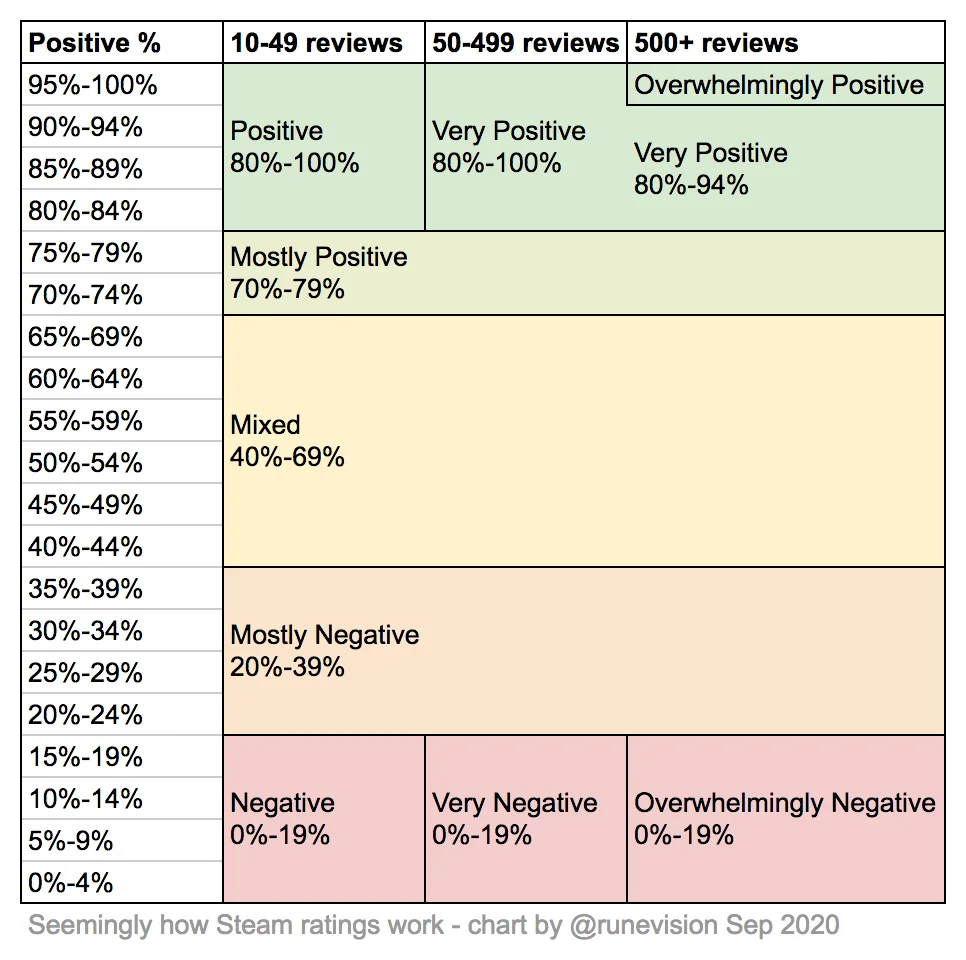

Источник фото: https://www.reddit.com/r/Steam/comments/ivz45n/what_does_the_steam_ratings_like_very_negative_or/?tl=ru

In [1058]:
df_final_2.loc[df_final_2['all_language_reviews_type'] == 'Крайне положительные', 'reviews_score'] = 10
df_final_2.loc[df_final_2['all_language_reviews_type'] == 'Очень положительные', 'reviews_score'] = 9
df_final_2.loc[df_final_2['all_language_reviews_type'] == 'В основном положительные', 'reviews_score'] = 8
df_final_2.loc[df_final_2['all_language_reviews_type'] == 'Положительные', 'reviews_score'] = 7
df_final_2.loc[df_final_2['all_language_reviews_type'] == 'Смешанные', 'reviews_score'] = 6
df_final_2.loc[df_final_2['all_language_reviews_type'] == 'Отрицательные', 'reviews_score'] = 5
df_final_2.loc[df_final_2['all_language_reviews_type'] == 'В основном отрицательные', 'reviews_score'] = 4
df_final_2.loc[df_final_2['all_language_reviews_type'] == 'Очень отрицательные', 'reviews_score'] = 3
df_final_2.loc[df_final_2['all_language_reviews_type'] == 'Крайне отрицательные', 'reviews_score'] = 2
df_final_2.loc[df_final['all_language_reviews_type'].astype(str).str.startswith('Обзоров пользователей:'), 'reviews_score'] = 1

### Признак genres

Для начала первично взглянем на значения в этом признаке

In [1059]:
df_final_2['genres'].str.split(',').explode().str.strip().value_counts()

genres
Indie                        8165
Adventure                    4612
Strategy                     2253
Role-playing (RPG)           2176
Simulator                    2144
Puzzle                       1749
Platform                     1131
Shooter                      1116
Arcade                        976
Point-and-click               431
Sport                         335
Turn-based strategy (TBS)     332
Visual Novel                  328
Racing                        323
Fighting                      259
Real Time Strategy (RTS)      228
Tactical                      214
Card & Board Game             187
Music                         183
Quiz/Trivia                    33
Pinball                         9
MOBA                            4
Name: count, dtype: int64

В первую очередь, уберем жанр Indie, т.к. у нас подразумевается что и так все игры - инди.

Перед этим посмотрим, если ли пропуски в данном столбце.

In [1060]:
df_final_2[df_final_2['genres'].isna()]

,steam_id,game_name,game_description_snippet,game_price,found_game_price,all_language_reviews_type,all_language_reviews_count,has_russian_reviews,all_russian_reviews_type,all_russian_reviews_count,...,igdb_id,type,first_release_date,genres,total_rating,total_rating_count,popularity_igdb,popularity_steam,popularity_twitch,reviews_score
2185,895040,CSC | Space MMO,CSC is a casual space MMO with fast-paced comb...,NaN,0.00000,Смешанные,484.00000,0.00000,NaN,NaN,...,118419,NaN,2020-09-03,NaN,40.00000,0.00000,NaN,NaN,NaN,6.00000
3753,539270,Mahjong,Познайте дзен! Заново откройте для себя извест...,599.00000,1.00000,Очень положительные,546.00000,0.00000,NaN,NaN,...,31012,NaN,2017-02-20,NaN,70.00000,1.00000,0.00002,NaN,NaN,9.00000
4036,292060,Titanfall - The Final Hours,"Written over the past four years, journalist G...",NaN,0.00000,В основном отрицательные,298.00000,0.00000,NaN,NaN,...,36336,Twitch,2014-04-16,NaN,50.00000,0.00000,0.00000,NaN,NaN,4.00000
4948,635550,Nocturnal Hunt,Be a wolf in a forest full of cruel hunters an...,NaN,0.00000,Очень положительные,60.00000,0.00000,NaN,NaN,...,75762,NaN,2017-11-01,NaN,60.00000,1.00000,0.00000,NaN,NaN,9.00000
10625,581630,Sword With Sauce,«Меч с Соусом» (Sword With Sauce) — это динами...,200.00000,1.00000,Очень положительные,5771.00000,1.00000,Очень положительные,359.00000,...,29725,"Twitter, YouTube, Official Website",2017-01-27,NaN,80.00000,4.00000,0.00002,NaN,NaN,9.00000
14574,914160,Zup! Arena,"Zup! Arena - это многопользовательская аркада,...",NaN,0.00000,Смешанные,97.00000,0.00000,NaN,NaN,...,110911,NaN,2018-12-20,NaN,40.00000,1.00000,0.00000,NaN,NaN,6.00000
16347,438030,Dead6hot,Fast-paced shooting in a frantic atmosphere! P...,42.00000,1.00000,Смешанные,328.00000,0.00000,NaN,NaN,...,33612,NaN,2016-02-01,NaN,40.00000,0.00000,NaN,NaN,NaN,6.00000
18059,618610,Endless Horde,"Орда здесь, чтобы съесть свой мозг и убить каж...",42.00000,1.00000,Смешанные,167.00000,0.00000,NaN,NaN,...,105890,NaN,2017-04-10,NaN,50.00000,1.00000,NaN,NaN,NaN,6.00000
19729,385080,Guardians of Victoria,Fans of challenging platformers will love this...,42.00000,1.00000,В основном отрицательные,120.00000,0.00000,NaN,NaN,...,34882,NaN,2016-04-29,NaN,40.00000,0.00000,NaN,NaN,NaN,4.00000
19791,446620,Zombie Training Simulator,Are you ready for the zombie apocalypse? We've...,419.00000,1.00000,Очень положительные,227.00000,0.00000,NaN,NaN,...,33451,Steam,2016-04-15,NaN,80.00000,1.00000,NaN,NaN,NaN,9.00000


Пропуски есть, но игр тут немного и, как минимум, для части их них можно вручную дописать жанр, даже учитывая описание или название. Но пока добавим для них уникальный жанр - UNDEFINED

In [1061]:
df_final_2['genres'] = df_final_2['genres'].fillna('UNDEFINED')

In [1062]:
df_final_2['genres'] = df_final_2['genres'].apply(lambda x: ', '.join(genre.strip() for genre in x.split(',') if genre.strip() != 'Indie')) # сначала разделяем строку на элементы по ",", применяем strip + проверяем, что значение не Indie и вновь собираем строку через ', '.join

In [1063]:
df_final_2['genres'].str.split(',').explode().str.strip().value_counts()

genres
Adventure                    4612
Strategy                     2253
Role-playing (RPG)           2176
Simulator                    2144
Puzzle                       1749
Platform                     1131
Shooter                      1116
Arcade                        976
                              524
Point-and-click               431
Sport                         335
Turn-based strategy (TBS)     332
Visual Novel                  328
Racing                        323
Fighting                      259
Real Time Strategy (RTS)      228
Tactical                      214
Card & Board Game             187
Music                         183
Quiz/Trivia                    33
UNDEFINED                      14
Pinball                         9
MOBA                            4
Name: count, dtype: int64

Можно заметить, что у нас появились по всей видимости игры без жанра - там был указан только Indie. К ним ничего не остается, кроме как установить ранее введеный "жанр" - UNDEFINED

In [1064]:
df_final_2.loc[df_final_2['genres'] == '', 'genres'] = 'UNDEFINED'

In [1065]:
df_final_2['genres'].str.split(',').explode().str.strip().value_counts()

genres
Adventure                    4612
Strategy                     2253
Role-playing (RPG)           2176
Simulator                    2144
Puzzle                       1749
Platform                     1131
Shooter                      1116
Arcade                        976
UNDEFINED                     538
Point-and-click               431
Sport                         335
Turn-based strategy (TBS)     332
Visual Novel                  328
Racing                        323
Fighting                      259
Real Time Strategy (RTS)      228
Tactical                      214
Card & Board Game             187
Music                         183
Quiz/Trivia                    33
Pinball                         9
MOBA                            4
Name: count, dtype: int64

## Выгрузим финальный датасет

In [1066]:
df_final_2.to_csv('../../data/df_final_3.csv')